In [1]:
from amocatlas import read

In [2]:
ds = read.rapid()

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series



In [3]:
print(ds) 

<xarray.Dataset> Size: 1MB
Dimensions:           (TIME: 14599)
Coordinates:
  * TIME              (TIME) datetime64[ns] 117kB 2004-04-02 ... 2024-03-27
Data variables:
    TRANS_0_800       (TIME) float64 117kB ...
    TRANS_800_1100    (TIME) float64 117kB ...
    TRANS_1100_3000   (TIME) float64 117kB ...
    TRANS_3000_5000   (TIME) float64 117kB ...
    TRANS_below_5000  (TIME) float64 117kB ...
    TRANS_FC          (TIME) float64 117kB ...
    TRANS_EKMAN       (TIME) float64 117kB ...
    TRANS_UMO         (TIME) float64 117kB ...
    MOC               (TIME) float64 117kB ...
Attributes: (12/39)
    title:                                 RAPID MOC timeseries
    summary:                               RAPID 26N transport estimates dataset
    description:                           RAPID 26N transport estimates dataset
    program:                               RAPID
    project:                               RAPID-AMOC 26°N array
    license:                               UK Ope

In [4]:
from amocatlas import read
import numpy as np

ds = read.fbc()
print(ds)                      # confirm the variable + time coord names

var = "TRANS_FBC"              # the FBC overflow transport (Sv)
time = ds["TIME"].values
values = ds[var].values.astype("float64")
dt_days = float(np.median(np.diff(time)) / np.timedelta64(1, "D"))
print(var, values.shape, "dt =", dt_days, "days")

Loading 1 Faroe Bank Channel dataset(s):
  0. OS_GSR_FBC_D_1995_2024.nc: Daily average of FBC overflow transport, estimated from an array of moored ADCPs in Sv

<xarray.Dataset> Size: 125kB
Dimensions:    (TIME: 10414, DEPTH: 1, LATITUDE: 2, LONGITUDE: 2)
Coordinates:
  * TIME       (TIME) datetime64[ns] 83kB 1995-11-14 1995-11-15 ... 2024-05-18
  * DEPTH      (DEPTH) float64 8B 9.969e+36
  * LATITUDE   (LATITUDE) float64 16B 61.5 61.36
  * LONGITUDE  (LONGITUDE) float64 16B -8.17 -8.36
Data variables:
    TRANS_FBC  (TIME, DEPTH) float32 42kB ...
Attributes: (12/73)
    title:                                 Faroe Bank Channel Overflow Volume...
    summary:                               Time series of volume transport of...
    description:                           FBC Overflow transport time series
    program:                               FBC
    project:                               B. Hansen, K. M. Larsen: NACLIM - ...
    source:                                subsurface moor

In [5]:
da     = ds["TRANS_FBC"].squeeze()          # drop the size-1 DEPTH dim
values = da.values.astype("float64")
time   = da["TIME"].values
print(values.shape)                          # want (10414,)

(10414,)


In [6]:
import numpy as np
steps = np.unique(np.diff(time) / np.timedelta64(1, "D"))
print("day-steps present:", steps)      
print("NaN count:", int(np.isnan(values).sum()))

day-steps present: [1.]
NaN count: 573


In [7]:
import matplotlib.pyplot as plt
from spectra_filtering import summary_stats   # the function from checkpoint 1

stats = summary_stats(values)
for k, v in stats.items():
    print(f"{k:>10}: {v}")

# raw series
plt.figure(figsize=(10, 3))
plt.plot(time, values, lw=0.4)
plt.ylabel("Sv"); plt.title("FBC overflow transport (daily)"); plt.show()

# distribution
plt.figure()
plt.hist(values[np.isfinite(values)], bins=40)
plt.xlabel("FBC overflow transport (Sv)"); plt.ylabel("count")
plt.title("FBC overflow transport — distribution"); plt.show()

ModuleNotFoundError: No module named 'spectra_filtering'

In [8]:
import sys, pathlib
here = pathlib.Path.cwd()
for cand in [here, *here.parents]:
    if (cand / "spectra_filtering" / "__init__.py").exists():
        root = cand
        break
else:
    raise FileNotFoundError(f"spectra_filtering not found above {here}")
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
print("repo root on path:", root)

repo root on path: /Users/mac/Downloads/assignment


In [9]:
from amocatlas import read
import numpy as np

ds = read.fbc()
print(ds)                      # confirm the variable + time coord names

var = "TRANS_FBC"              # the FBC overflow transport (Sv)
time = ds["TIME"].values
values = ds[var].values.astype("float64")
dt_days = float(np.median(np.diff(time)) / np.timedelta64(1, "D"))
print(var, values.shape, "dt =", dt_days, "days")

Loading 1 Faroe Bank Channel dataset(s):
  0. OS_GSR_FBC_D_1995_2024.nc: Daily average of FBC overflow transport, estimated from an array of moored ADCPs in Sv

<xarray.Dataset> Size: 125kB
Dimensions:    (TIME: 10414, DEPTH: 1, LATITUDE: 2, LONGITUDE: 2)
Coordinates:
  * TIME       (TIME) datetime64[ns] 83kB 1995-11-14 1995-11-15 ... 2024-05-18
  * DEPTH      (DEPTH) float64 8B 9.969e+36
  * LATITUDE   (LATITUDE) float64 16B 61.5 61.36
  * LONGITUDE  (LONGITUDE) float64 16B -8.17 -8.36
Data variables:
    TRANS_FBC  (TIME, DEPTH) float32 42kB ...
Attributes: (12/73)
    title:                                 Faroe Bank Channel Overflow Volume...
    summary:                               Time series of volume transport of...
    description:                           FBC Overflow transport time series
    program:                               FBC
    project:                               B. Hansen, K. M. Larsen: NACLIM - ...
    source:                                subsurface moor

In [10]:
da     = ds["TRANS_FBC"].squeeze()          # drop the size-1 DEPTH dim
values = da.values.astype("float64")
time   = da["TIME"].values
print(values.shape)  

(10414,)


In [11]:
import numpy as np
steps = np.unique(np.diff(time) / np.timedelta64(1, "D"))
print("day-steps present:", steps)      
print("NaN count:", int(np.isnan(values).sum()))

day-steps present: [1.]
NaN count: 573


         n: 10414
 n_missing: 573
      mean: 2.1994766772078034
       std: 0.5905036439900442
    median: 2.1700000762939453
       min: 0.5
       max: 4.860000133514404
     range: 4.360000133514404


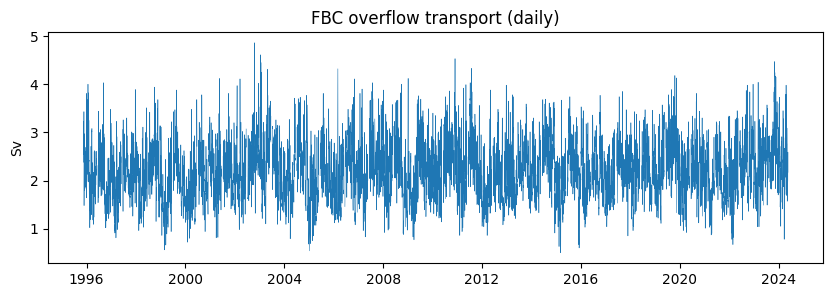

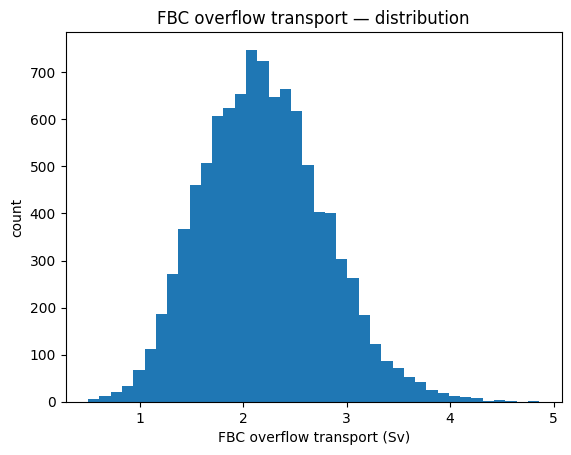

In [12]:
import matplotlib.pyplot as plt
from spectra_filtering import summary_stats   # the function from checkpoint 1

stats = summary_stats(values)
for k, v in stats.items():
    print(f"{k:>10}: {v}")

# raw series
plt.figure(figsize=(10, 3))
plt.plot(time, values, lw=0.4)
plt.ylabel("Sv"); plt.title("FBC overflow transport (daily)"); plt.show()

# distribution
plt.figure()
plt.hist(values[np.isfinite(values)], bins=40)
plt.xlabel("FBC overflow transport (Sv)"); plt.ylabel("count")
plt.title("FBC overflow transport — distribution"); plt.show()